# $\text{Experiment for Trefoil Knot}$

##### $\text{Import Dependencies}$

In [1]:
import numpy as np
import pandas as pd
from qiskit.quantum_info import DensityMatrix, partial_trace

# Visualization Module
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.graph_objects as go

mpl.rcParams['font.family'] = 'Times New Roman'

# Statistical Module
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from scipy.stats import shapiro
from scipy.stats import kstest

# Integration Directory
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

##### $\text{Load Khovanov Laplacian Matrices for Trefoil Knot}$

In [2]:
from data.knot import k3_1

Delta = k3_1()
print(f"""
The Matrices:
{Delta}

Shape: {Delta.shape}
""")


The Matrices:
[[ 3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  3.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  3.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  5.  0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  4.  0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  5.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  4.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0

This matrix has dimension 30, and all its elements are real numbers

### $\text{A. Matrix Testing}$

##### $\text{Hermitian Test for } \text{pad}(\Delta) (\alpha = 1)$

In [3]:
from src.helper import padding

Delta_pad = padding(Delta, 1)

print(f"""
Is the matrix Hermitian? {np.allclose(Delta_pad, Delta_pad.conj().T)}
""")

eigenvalue_pad, _ = np.linalg.eigh(Delta_pad)

print(f"""
The list of eigenvalues:
{eigenvalue_pad}

The number of eigenvalues is 0: {sum(eigenvalue_pad < 1e-10)}
""")


Is the matrix Hermitian? True


The list of eigenvalues:
[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.83133613e-16
 6.12422578e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.46418946e+00 1.46791111e+00
 2.45647949e+00 2.65270364e+00 3.00000000e+00 3.00000000e+00
 3.00000000e+00 3.00000000e+00 3.00000000e+00 3.00000000e+00
 3.00000000e+00 3.00000000e+00 3.72407902e+00 4.00000000e+00
 4.72446005e+00 4.87938524e+00 6.00000000e+00 6.00000000e+00
 6.00000000e+00 6.00000000e+00 6.00000000e+00 7.01836940e+00]

The number of eigenvalues is 0: 4



This matrix is ​​Hermitian and has four eigenvalues ​​equal to $0$. This indicates that the Khovanov Laplacian matrix of the Trefoil knot has a global Betti number of $4$. This is also consistent with reference data from the Knot Atlas https://katlas.org/wiki/3_1

On the other hand, $\alpha > 0$ will not change the value of the Betti numbers.

##### $\text{Density Matrix Test for Gibbs State } (\mu = 3)$

In [4]:
from src.helper import gibbs_state

keadaan_gibbs = gibbs_state(Delta, 3)

print(f"""
Is the matrix Hermitian? {np.allclose(keadaan_gibbs, keadaan_gibbs.conj().T)}
""")

eigenvalue_gibbs, _ = np.linalg.eigh(keadaan_gibbs)

print(f"""
The list of eigenvalues:
{eigenvalue_gibbs}

Are all the eigenvalues positive? {bool(sum(eigenvalue_gibbs >= 0) == eigenvalue_gibbs.shape)}
""")

print(f"Number of traces: {np.trace(keadaan_gibbs)}")


Is the matrix Hermitian? True


The list of eigenvalues:
[1.65528715e-10 3.51309543e-09 3.51309543e-09 3.51309543e-09
 3.51309544e-09 3.51309546e-09 1.01325876e-07 1.61276034e-07
 1.41728385e-06 3.24302065e-06 2.84669071e-05 2.84669071e-05
 2.84669071e-05 2.84669071e-05 2.84669071e-05 2.84669071e-05
 2.84669071e-05 2.84669071e-05 8.06913454e-05 1.45373134e-04
 2.82145762e-03 2.85313559e-03 1.14843700e-02 1.14843700e-02
 1.14843700e-02 3.67346058e-02 2.30669738e-01 2.30669738e-01
 2.30669738e-01 2.30669738e-01]

Are all the eigenvalues positive? True

Number of traces: 1.0


This matrix is ​​Hermitian, positive semi-definite, and has a trace of $1$. Therefore, it qualifies as a density matrix.

On the other hand, Gibbs state requires the $\Delta$ prior to padding, as padding beforehand would corrupt the Gibbs state information. Subsequently, padding is performed using $\alpha = 0$ to avoid increasing the trace.

##### $\text{Unitary Test for Unitary Operator } (t = 2)$

In [5]:
from src.helper import unitary_operator

operator_uniter = unitary_operator(Delta_pad, 2)

print(f"""
Is the matrix unitary? {np.allclose(operator_uniter @ operator_uniter.conj().T, np.eye(operator_uniter.shape[0]))}
""")


Is the matrix unitary? True



The unitary operator requires a delta after padding with $\alpha > 0$ because it needs to adjust the dimensions to the qubit. $\alpha > 0$ is used to avoid adding zero eigenvalues, so the value of the betti number is not affected.

### $\text{B. Produce the Experimental Data}$

In [6]:
from src.helper import QuantumSimulation
from src.helper import trace

# =================================================
# Simulation Function for X Combination Parameters
# =================================================
def estimasi_betti(mu, t, qubit_resolusi):
    # 1. Define the Parameters [mu, t, k]
    parameters = [mu, t, qubit_resolusi]
 
    # 2. Quantum Simulation
    total_qubits, final_rho = QuantumSimulation(Delta, parameters)

    # 3. Betti Number Estimation
    rho_total = DensityMatrix(final_rho)
    rho_phase = partial_trace(
        rho_total,
        list(np.arange(qubit_resolusi, total_qubits))
    )
    chain_dimension = trace(Delta, mu)
    probabilities = np.real(np.diag(rho_phase.data))
    probability_zero = probabilities[0]
    kernel_dimension = chain_dimension * probability_zero
    error = kernel_dimension - 4

    return {
        "mu": mu,
        "t": t,
        "k": qubit_resolusi,
        "trace_gibbs": chain_dimension,
        "probabilitas": probability_zero,
        "betti_global": kernel_dimension,
        "error": error
    }

# ==================================
# Reduced FLFD Parameter Variations
# ==================================
data = [
    [0, 2, 3],
    [1, 2, 3],
    [2, 2, 3],
    [3, 2, 3],
    [4, 2, 3],

    [2, 0, 3],
    [2, 1, 3],
    [2, 2, 3],
    [2, 3, 3],
    [2, 4, 3],

    [2, 2, 1],
    [2, 2, 2],
    [2, 2, 3],
    [2, 2, 4],
    [2, 2, 5],

    [0, 0, 3],
    [1, 1, 3],
    [2, 2, 3],
    [3, 3, 3],
    [4, 4, 3],

    [0, 2, 1],
    [1, 2, 2],
    [2, 2, 3],
    [3, 2, 4],
    [4, 2, 5],

    [2, 0, 1],
    [2, 1, 2],
    [2, 2, 3],
    [2, 3, 4],
    [2, 4, 5],

    [0, 0, 1],
    [1, 1, 2],
    [2, 2, 3],
    [3, 3, 4],
    [4, 4, 5]
]

# Logging
data_simulasi = []
for order, value in enumerate(data):
    print(f"Running: mu={value[0]}, t={value[1]}, k={value[2]} ===> {order + 1}/{len(data)}")
    out = estimasi_betti(value[0], value[1], value[2])
    data_simulasi.append(out)

Running: mu=0, t=2, k=3 ===> 1/35


Running: mu=1, t=2, k=3 ===> 2/35
Running: mu=2, t=2, k=3 ===> 3/35
Running: mu=3, t=2, k=3 ===> 4/35
Running: mu=4, t=2, k=3 ===> 5/35
Running: mu=2, t=0, k=3 ===> 6/35
Running: mu=2, t=1, k=3 ===> 7/35
Running: mu=2, t=2, k=3 ===> 8/35
Running: mu=2, t=3, k=3 ===> 9/35
Running: mu=2, t=4, k=3 ===> 10/35
Running: mu=2, t=2, k=1 ===> 11/35
Running: mu=2, t=2, k=2 ===> 12/35
Running: mu=2, t=2, k=3 ===> 13/35
Running: mu=2, t=2, k=4 ===> 14/35
Running: mu=2, t=2, k=5 ===> 15/35
Running: mu=0, t=0, k=3 ===> 16/35
Running: mu=1, t=1, k=3 ===> 17/35
Running: mu=2, t=2, k=3 ===> 18/35
Running: mu=3, t=3, k=3 ===> 19/35
Running: mu=4, t=4, k=3 ===> 20/35
Running: mu=0, t=2, k=1 ===> 21/35
Running: mu=1, t=2, k=2 ===> 22/35
Running: mu=2, t=2, k=3 ===> 23/35
Running: mu=3, t=2, k=4 ===> 24/35
Running: mu=4, t=2, k=5 ===> 25/35
Running: mu=2, t=0, k=1 ===> 26/35
Running: mu=2, t=1, k=2 ===> 27/35
Running: mu=2, t=2, k=3 ===> 28/35
Running: mu=2, t=3, k=4 ===> 29/35
Running: mu=2, t=4, k=5 ===>

##### $\text{Converting to Data Frame}$

In [7]:
data_analisis = pd.DataFrame(data_simulasi)
data_analisis

,mu,t,k,trace_gibbs,probabilitas,betti_global,error
0,0,2,3,30.000000,0.333359,10.000784,6.000784
1,1,2,3,6.734057,0.640923,4.316010,0.316010
2,2,2,3,4.839611,0.833998,4.036227,0.036227
3,3,2,3,4.335202,0.925302,4.011371,0.011371
4,4,2,3,4.147074,0.965792,4.005210,0.005210
5,2,0,3,4.839611,1.000000,4.839611,0.839611
6,2,1,3,4.839611,0.834198,4.037194,0.037194
7,2,2,3,4.839611,0.833998,4.036227,0.036227
8,2,3,3,4.839611,0.828676,4.010470,0.010470
9,2,4,3,4.839611,0.835206,4.042071,0.042071


### $\text{C. Descriptive Analysis}$

In [8]:
data_analisis.describe()

,mu,t,k,trace_gibbs,probabilitas,betti_global,error
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2.000000,2.000000,3.000000,7.794798,0.841591,6.267051,2.267051
std,1.084652,1.084652,1.084652,8.123700,0.135266,6.648405,6.648405
min,0.000000,0.000000,1.000000,4.147074,0.333359,4.000144,0.000144
25%,2.000000,2.000000,3.000000,4.839611,0.827179,4.003899,0.003899
50%,2.000000,2.000000,3.000000,4.839611,0.833998,4.036227,0.036227
75%,2.000000,2.000000,3.000000,4.839611,0.924483,4.330353,0.330353
max,4.000000,4.000000,5.000000,30.000000,1.000000,30.000000,26.000000


The data is balanced, with all features having $35$ samples

The smallest error is $0.000144$ when $\mu$ and $t$ are high. While the largest error is $26$ when $\mu$ and $t$ are $0$

In [9]:
data_analisis.groupby("mu")["error"].mean()

mu
0    18.774971
1     0.377457
2     0.142725
3     0.004358
4     0.001963
Name: error, dtype: float64

Roughly speaking, the higher the value of $\mu$, the smaller the Betti number estimation error $E$ will be

In [10]:
data_analisis.groupby("t")["error"].mean()

t
0    13.419806
1     0.252533
2     1.294352
3     0.004728
4     0.011453
Name: error, dtype: float64

Roughly speaking, the higher the value of $t$, the smaller the Betti number estimation error $E$ becomes

In [11]:
data_analisis.groupby("k")["error"].mean()

k
1    11.070852
2     0.358549
3     1.769361
4     0.002059
5     0.000769
Name: error, dtype: float64

Roughly speaking, the higher the value of $k$, the smaller the Betti number estimation error $E$ will be

### $\text{D. Quadratic Regression Model}$

In [12]:
# Experimental Data
X = data_analisis[["mu", "t", "k"]]

# Quadratic and Interaction Feature
X["mu2"] = X["mu"]**2
X["t2"] = X["t"]**2
X["k2"] = X["k"]**2
X["mu_t"] = X["mu"] * X["t"]
X["mu_k"] = X["mu"] * X["k"]
X["t_k"] = X["t"] * X["k"]

X = sm.add_constant(X)
y = data_analisis["error"]

# Apply the Ordinary Least Squares
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  error   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     12.77
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           2.49e-07
Time:                        08:22:22   Log-Likelihood:                -85.315
No. Observations:                  35   AIC:                             190.6
Df Residuals:                      25   BIC:                             206.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.8643      3.581      6.664      0.0

The model performs reasonably well, with an $R^2$ score of $0.821$, and is globally significant. Individually, the parameters $\mu$ and $t$, are statistically significant

### $\text{E. Residual Normality Test}$

In [13]:
# Residual Data and Fit Value
residual = model.resid
fitted = model.fittedvalues

##### $\text{Residual Histogram}$

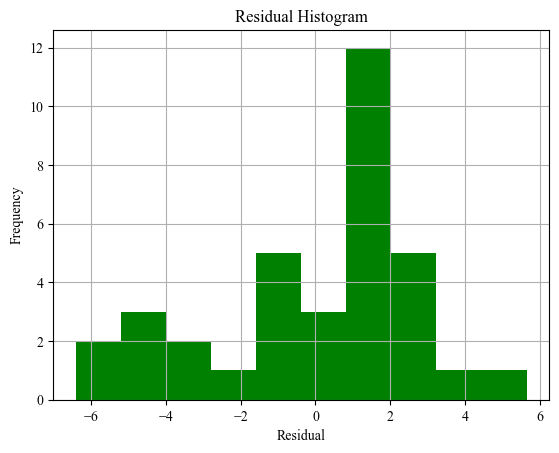

In [14]:
plt.hist(residual, bins=10, color='green')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Histogram")
plt.grid()
plt.show()

Roughly speaking, the residual distribution is bell-shaped. Therefore, it can be identified as a **normal distribution**

##### $\text{Shapiro-Wilk Test}$

In [15]:
stat, p = shapiro(residual)
print("p-value:", p)

p-value: 0.08353441148658815


The residuals can be identified as following a **normal distribution** because $p > 0.05$ in the Shapiro-Wilk test

##### $\text{Kolmogorov-Simirnov Test}$

In [16]:
ks = kstest(residual, 'norm', args=(np.mean(residual), np.std(residual)))
print(f"p-value: {ks[1]}")

p-value: 0.1860056796464713


The residuals can be identified as following a **normal distribution** because $p > 0.05$ in the Kolmogorov-Smirnov test

### $\text{F. Homoscedasticity Test}$

##### $\text{White Test}$

In [17]:
test = het_white(residual, X)
labels = ['LM Stat', 'LM p-value', 'F Stat', 'F p-value']
white = dict(zip(labels, test))
print(F"P-value: {white["LM p-value"]}")

P-value: 0.10974908878314547


The residuals can be identified as **homoskedastic** because $p > 0.05$ in the White test

### $\text{G. Response Surface Visualization}$

##### $\mu \text{ vs } t \text{ Section}$

In [18]:
mu_range = np.linspace(0, 4, 100)
t_range = np.linspace(0, 4, 100)

MU, T = np.meshgrid(mu_range, t_range)
K = 3 # Fix point

# Error Models
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

##### $\mu \text{ vs } t \text{ Surface Plot}$

In [19]:
fig = go.Figure(data=[
    go.Surface(
        x=MU,
        y=T,
        z=ERROR,
        colorscale='Viridis',
        colorbar=dict(
                title='Error',
                x=0.56,        
                len=0.45,      
                thickness=16
            )
    )
])

fig.update_layout(
    title=f"Surface Plot: mu vs t (k={K})",
    scene=dict(
        xaxis_title="mu",
        yaxis_title="t",
        zaxis_title="Error"
    )
)

fig.show()

##### $\mu \text{ vs } t \text{ Contour Plot}$

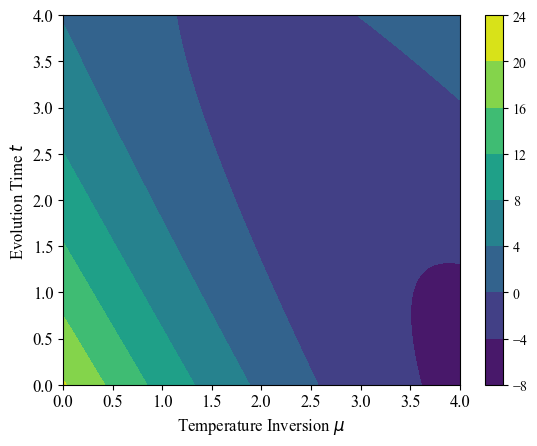

In [20]:
plt.figure()
cp = plt.contourf(MU, T, ERROR)
plt.colorbar(cp)
plt.xlabel("Temperature Inversion $\\mu$", fontsize=12)
plt.ylabel("Evolution Time $t$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

##### $\mu \text{ vs } k \text{ Section}$

In [21]:
mu_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

MU, K = np.meshgrid(mu_range, k_range)
T = 2 # Fix point

# Error Models
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

##### $\mu \text{ vs } k \text{ Surface Plot}$

In [22]:
fig = go.Figure(data=[
    go.Surface(
        x=MU,
        y=K,
        z=ERROR,
        colorscale='viridis',
        colorbar=dict(
                title='Error',
                x=0.58,        
                len=0.45,      
                thickness=16   
            ) )
])

fig.update_layout(
    title=f"Surface Plot: mu vs k (t={T})",
    scene=dict(
        xaxis_title="mu",
        yaxis_title="k",
        zaxis_title="Error"
    )
)

fig.show()

##### $\mu \text{ vs } k \text{ Contour Plot}$

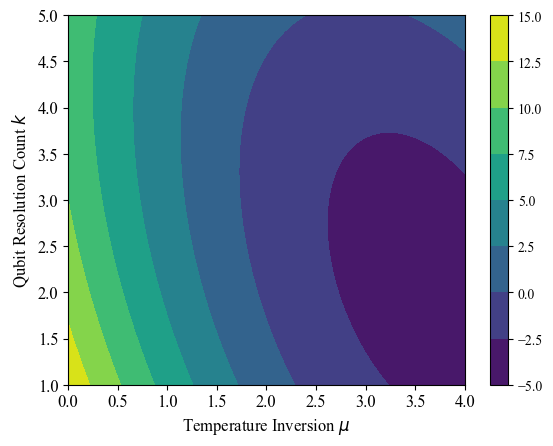

In [23]:
plt.figure()
cp = plt.contourf(MU, K, ERROR, cmap="viridis")
plt.colorbar(cp)
plt.xlabel("Temperature Inversion $\\mu$", fontsize=12)
plt.ylabel("Qubit Resolution Count $k$", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

##### $t \text{ vs } k \text{ Section}$

In [24]:
t_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

T, K = np.meshgrid(t_range, k_range)
MU = 2 # Fix point

# Error Models
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

##### $t \text{ vs } k \text{ Surface Plot}$

In [25]:
fig = go.Figure(data=[
    go.Surface(
        x=T,
        y=K,
        z=ERROR,
        colorscale='viridis',
        colorbar=dict(
                title='Error',
                x=0.57,
                len=0.45,
                thickness=16
            ) )
])

fig.update_layout(
    title=f"Surface Plot: t vs k (mu={MU})",
    scene=dict(
        xaxis_title="t",
        yaxis_title="k",
        zaxis_title="Error"
    )
)

fig.show()

##### $t \text{ vs } k \text{ Contour Plot}$

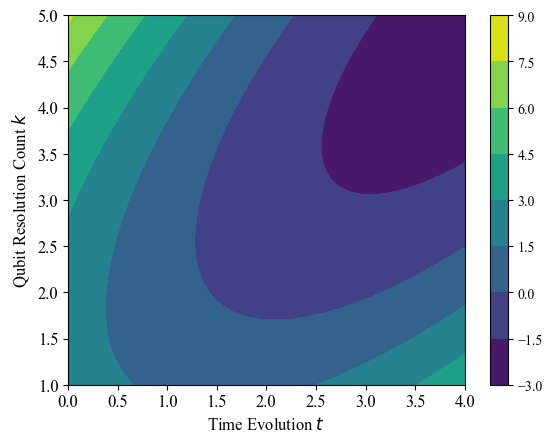

In [26]:
plt.figure()
cp = plt.contourf(T, K, ERROR, cmap="viridis")
plt.colorbar(cp)
plt.xlabel("Time Evolution $t$", fontsize=12)
plt.ylabel("Qubit Resolution Count $k$", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()